Obiettivo del Progetto
L'obiettivo è esplorare due metodologie distinte (DBSCAN e Elbow Method tramite Inertia/WCSS) per determinare il numero ottimale di cluster $K$ su un dataset non etichettato. Successivamente, si applicherà l'algoritmo K-Means utilizzando il valore di $K$ identificato. Per questo esercizio verrà utilizzato il dataset Iris, ignorando le etichette di classe originali.

1. Data Exploration & Preprocessing
Caricamento e Analisi: Caricare il dataset e fornire un'analisi descrittiva iniziale (es. df.describe()).
Standardizzazione: Applicare la standardizzazione alle feature ($X$) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

2. Stima di $K$ con DBSCAN
Eseguire l'algoritmo DBSCAN iterativamente per analizzare la struttura dei dati basata sulla densità.
Parametri di Iterazione:$min\_samples = 5$$eps \in [0.35, 0.45, 0.55]$
$min\_samples = 5$
$eps \in [0.35, 0.45, 0.55]$
Metriche da determinare per ogni esecuzione:Il numero di cluster $K$ identificati.Il numero di punti rumorosi (label -1).
Il numero di cluster $K$ identificati.
Il numero di punti rumorosi (label -1).
Selezione: Individuare il numero di cluster $K$ più plausibile tra i risultati ottenuti.

3. Stima di $K$ con Elbow Method

Utilizzare K-Means per identificare il $K$ ottimale analizzando l'inerzia (o WCSS: Within Cluster Sum of Squares).

Configurazione:Algoritmo: K-Means.Range di $K$: da 1 a 10.Algoritmo: K-Means.Range di $K$: da 1 a 10.Visualizzazione:Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e $K$ sull'asse X).Identificazione del "punto di gomito" (dove la curva si piega).Inserimento di un asse verticale in corrispondenza del valore $x = K$ scelto.Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e $K$ sull'asse X).Identificazione del "punto di gomito" (dove la curva si piega).Inserimento di un asse verticale in corrispondenza del valore $x = K$ scelto.

4. Applicazione Finale & Visualizzazione
Clusterizzazione Definitiva: Stabilire il $K$ finale e applicare il K-Means sul dataset standardizzato.
Valutazione: Calcolare il Silhouette Score per valutare la coesione interna e la separazione dei cluster.
Visualizzazione Risultati:Plot dei dati proiettati in 2D (utilizzando le prime due feature).+1Rappresentazione dei centroidi dei cluster.
Plot dei dati proiettati in 2D (utilizzando le prime due feature).+1
Rappresentazione dei centroidi dei cluster.

In [ ]:
# caricamento librerie
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

1. Data Exploration e Preprocessing

In [3]:
# caricamento dataset per analisi
X, y = make_moons(n_samples=400, noise=0.07, random_state=42)
print(f"X shape: {X.shape}\ny shape: {y.shape}")

X shape: (400, 2)
y shape: (400,)


In [4]:
# applicare standardizzazione ai dati affinché abbiano media 0 e deviazione standard 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


2. Stima di K con DBSCAN

In [5]:
# esecuzione DBSCAN sui dati standardizzati con eps=[0.35, 0.45, 0.55]
eps_values = [0.35, 0.45, 0.55]
min_samples = 5
dbscan_results = []

# determinare per ogni eps il numero di cluster identificati e il numero di punti classificati come rumore

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X_scaled)
    labels = dbscan.labels_
    dbscan_results.append((eps, labels))

# visualizzare i risultati per ogni eps
for eps, labels in dbscan_results:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps: {eps}, Number of clusters: {n_clusters}, Number of noise points: {n_noise}")

# selezionare il numero di cluster più plausibile con i risultati ottenuti
best_eps = 0.45  # esempio di eps selezionato in base ai risultati
dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
dbscan.fit(X_scaled)
labels = dbscan.labels_


eps: 0.35, Number of clusters: 2, Number of noise points: 1
eps: 0.45, Number of clusters: 2, Number of noise points: 0
eps: 0.55, Number of clusters: 2, Number of noise points: 0


3. Stima di K con Elbow Method

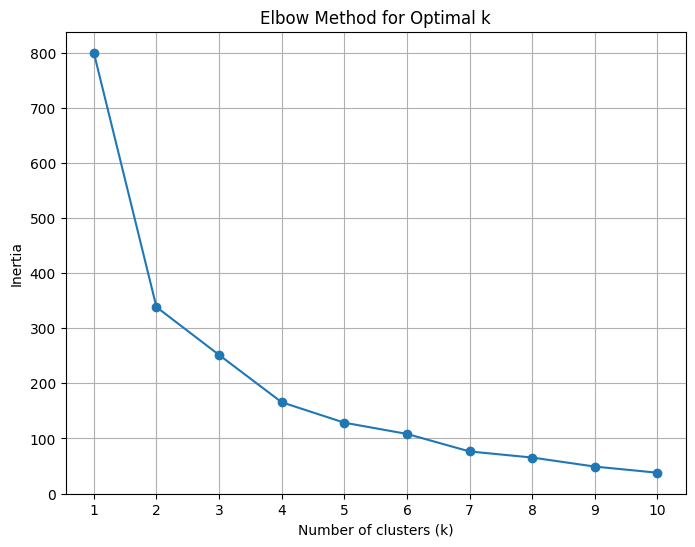

In [7]:
# utilizzare Kmeans per identificare il numero k di cluster ottimale tramite inercia

inertia_values = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# visualizzare il grafico dell'inercia per identificare il punto di "gomito"
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid()
plt.show()

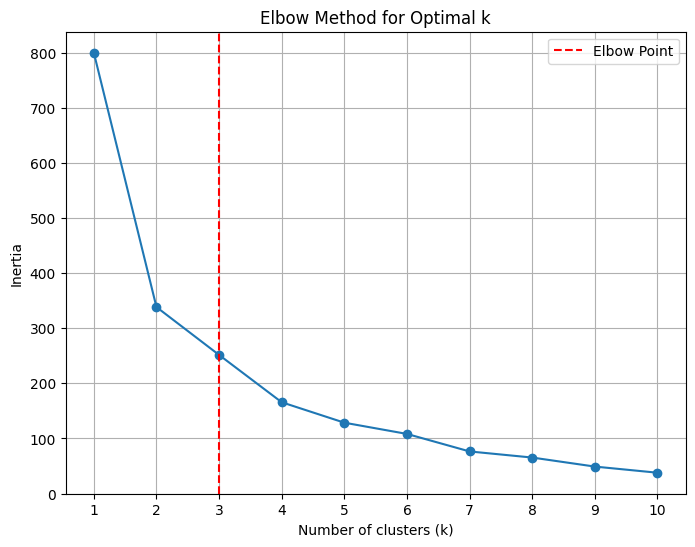

In [8]:
# inserimento di asse verticale per evidenziare il punto di gomito
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker="o")
plt.axvline(x=3, color="red", linestyle="--", label="Elbow Point")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid()
plt.legend()
plt.show()


4. Applicazione Finale e Visualizzazione

In [9]:
# stabilito il k ottimale, eseguire KMeans con k=3 sul dataset standardizzato e visualizzare i risultati
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [11]:
# calcolo del silhouette score per valutare la qualità del clustering ottenuto con KMeans
from sklearn.metrics import silhouette_score
silhouette_kmeans = silhouette_score(X_scaled, clusters)

print(f"Silhouette Score for KMeans: {silhouette_kmeans:.4f}")


Silhouette Score for KMeans: 0.4376


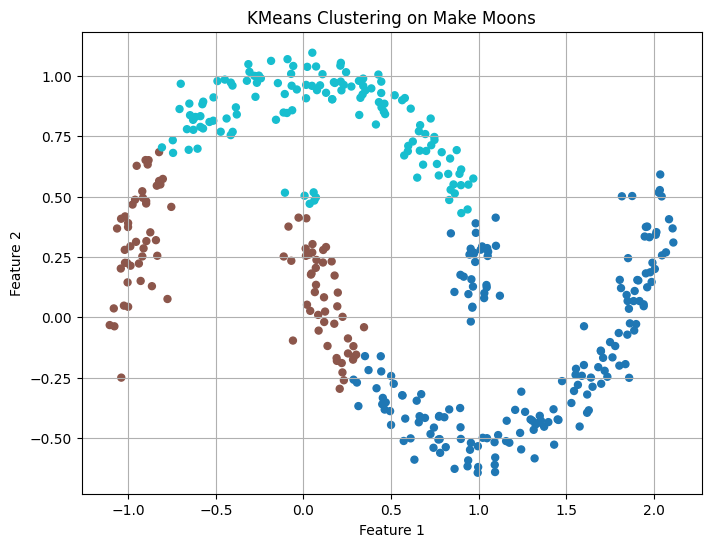

In [12]:
# visualizzazione delle prime due feature del dataset con i cluster identificati da KMeans
plt.figure(figsize=(8, 6))
plt.title("KMeans Clustering on Make Moons")
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="tab10", s=25)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.show()


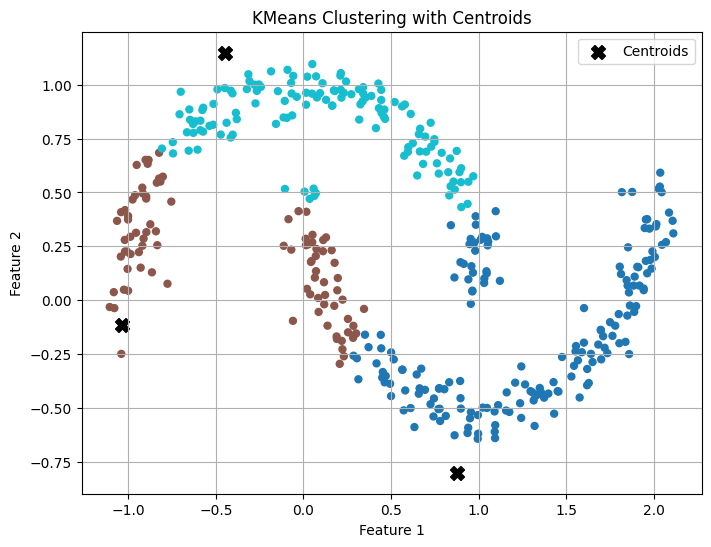

In [13]:
# rappresentazione grafica dei centroidi identificati da KMeans
centroids = kmeans.cluster_centers_
plt.figure(figsize=(8, 6))
plt.title("KMeans Clustering with Centroids")
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap="tab10", s=25)
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=100, label="Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()
plt.legend()
plt.show()
